In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
import umap
import numpy as np

In [13]:
day24 = pd.read_csv("/Users/hannahbolen/Desktop/image_analysis/masks_and_results/o8p_day24_s12_filtered2.csv", index_col="label").drop(columns=["nucleus_percent_touching_1", "nucleus_bounds"])
day24 = day24[['foci_count'] + [col for col in day24.columns if col != 'foci_count']]
day24

,foci_count,nucleus_intensity_min,nucleus_intensity_std,nucleus_eccentricity,nucleus_area,nucleus_i,nucleus_j,nucleus_intensity_mean,nucleus_intensity_max,foci_area,nucleus_number_neighbors_1,nucleus_first_neighbor_distance,nucleus_second_neighbor_distance,nucleus_angle_between_neighbors
label,,,,,,,,,,,,,,
1,12,85.0,159.698169,0.743646,1697.0,1166.935180,22728.589864,500.892752,922.0,169,0,1830.232334,1883.670224,2.169877
2,15,166.0,376.963702,0.817820,2594.0,2176.071704,17440.177718,1135.093292,2284.0,300,0,41.711648,516.400061,125.916065
3,6,213.0,87.990655,0.797968,149.0,2155.067114,17476.214765,401.624161,660.0,81,0,41.711648,541.922014,50.510021
4,14,474.0,438.733909,0.695011,1383.0,2329.756327,15285.031092,1990.001446,3273.0,292,0,646.259672,1137.524833,5.236467
5,14,0.0,533.434879,0.801312,6062.0,2689.936490,17389.069944,363.400198,2269.0,132,0,418.537702,428.435376,5.723243
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5322,12,180.0,361.207450,0.583371,1090.0,38735.823853,15098.579817,793.711009,1857.0,545,0,413.184364,419.753352,54.289403
5323,9,97.0,191.929634,0.810368,1202.0,38995.897671,18955.308652,512.282030,1014.0,639,0,48.423487,155.828229,58.332640
5324,7,121.0,258.455053,0.787711,1103.0,38994.583862,18906.902992,654.471442,1498.0,509,0,48.423487,136.764160,104.128721


In [21]:
len(day7)

3148

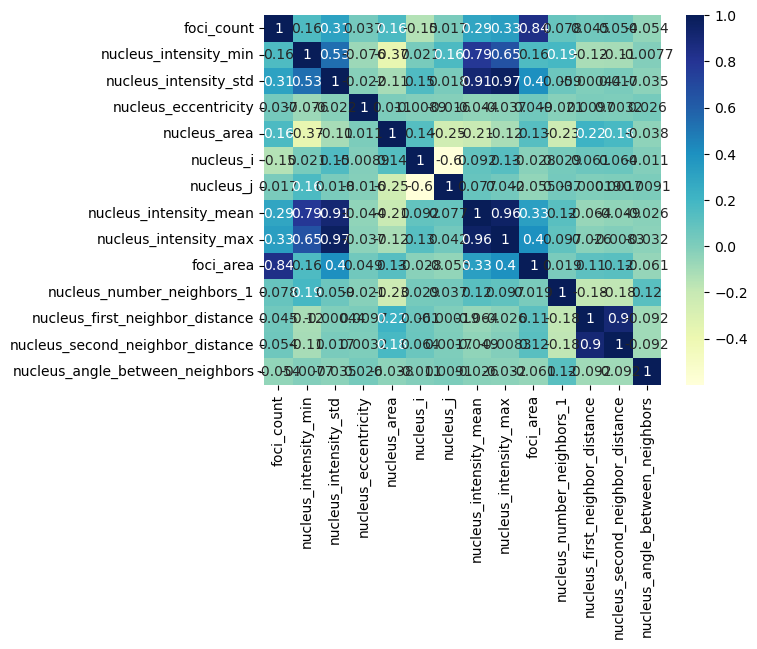

<Figure size 2000x2000 with 0 Axes>

In [16]:
# Compute correlation matrix
co_mtx = day24[day24["nucleus_intensity_mean"]>1000].corr(numeric_only=True)

# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)
plt.figure(figsize=(20,20))
# Display heatmap
plt.show()

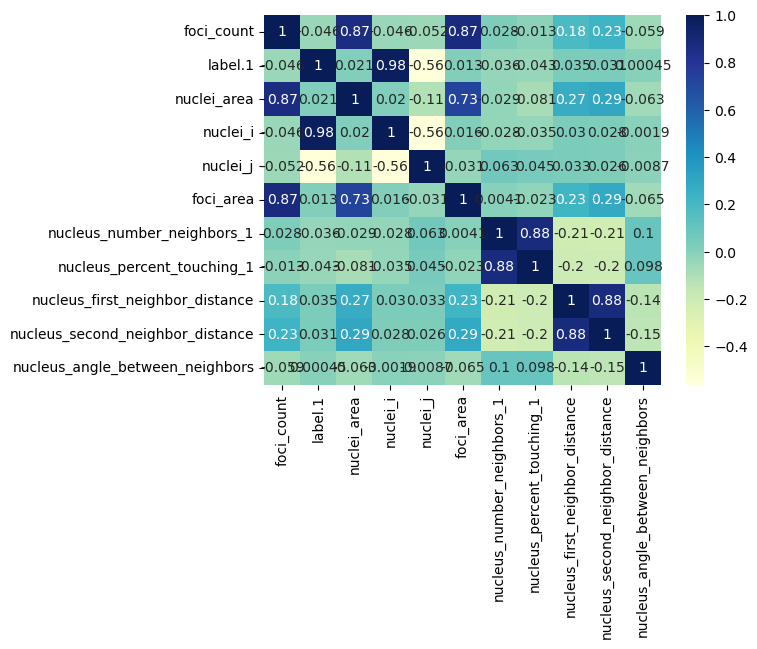

<Figure size 2000x2000 with 0 Axes>

In [14]:
# Compute correlation matrix
co_mtx = day24.corr(numeric_only=True)

# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)
plt.figure(figsize=(20,20))
# Display heatmap
plt.show()

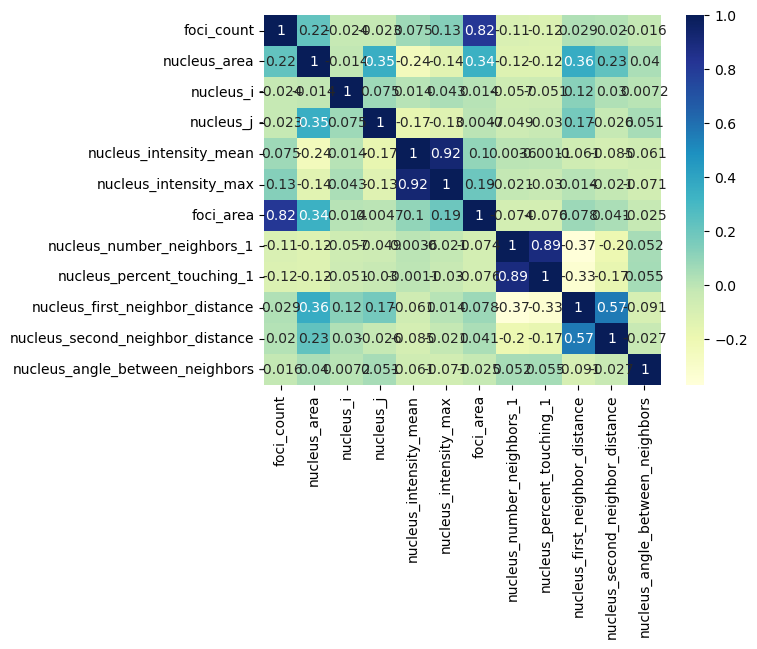

<Figure size 2000x2000 with 0 Axes>

In [15]:
# Compute correlation matrix
co_mtx = ctrl_1gray.corr(numeric_only=True)

# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)
plt.figure(figsize=(20,20))
# Display heatmap
plt.show()

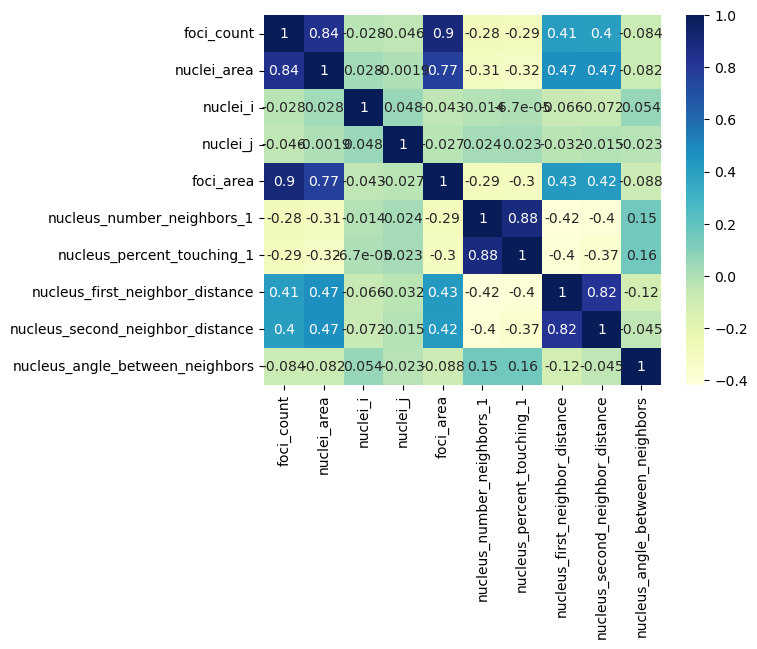

<Figure size 2000x2000 with 0 Axes>

In [56]:
# Compute correlation matrix
co_mtx = df_clean.corr(numeric_only=True)

# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)
plt.figure(figsize=(20,20))
# Display heatmap
plt.show()

In [59]:
df_clean = df

In [19]:
day24["log_foci"] = np.log1p(day24["foci_count"].copy())


# df_clean["log_foci_area"] = np.log1p(df_clean["foci_area"])
# df_clean["log_second_neighbor_distance"] = np.log1p(df_clean["nucleus_second_neighbor_distance"])
# df_clean["log_first_neighbor_distance"] = np.log1p(df_clean["nucleus_first_neighbor_distance"])

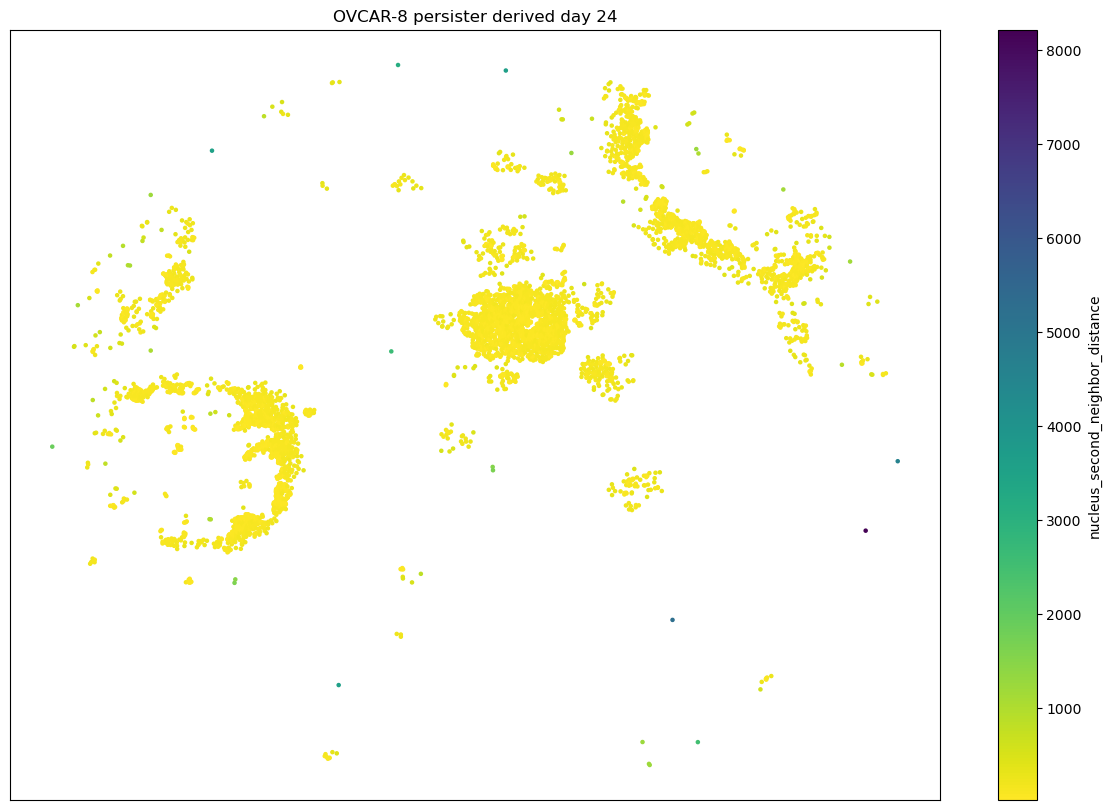

In [17]:
plt.figure(figsize=(15,10))

plt.scatter(
    day24["nucleus_i"],
    day24["nucleus_j"],
    c=day24["nucleus_second_neighbor_distance"],
    s=5,
    cmap="viridis_r"
)
plt.xticks(ticks=[])
plt.yticks(ticks=[])
plt.colorbar(label="nucleus_second_neighbor_distance")
plt.title("OVCAR-8 persister derived day 24")
plt.gca().invert_yaxis()
plt.show()

In [69]:
# constants -- processing
umPerPx = 0.325
nucleiThreshold = 50
nucleiMin = 150/umPerPx**2
nucleiMax = 12000/umPerPx**2
nucleiMean = 300/umPerPx**2

In [71]:
nucleiMin

1420.118343195266

(array([7.800e+01, 6.050e+02, 1.128e+03, 1.238e+03, 1.004e+03, 6.800e+02,
        3.180e+02, 1.230e+02, 6.800e+01, 3.300e+01, 1.600e+01, 1.000e+01,
        3.000e+00, 5.000e+00, 5.000e+00, 1.000e+00, 2.000e+00, 1.000e+00,
        1.000e+00, 2.000e+00, 0.000e+00, 2.000e+00, 1.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00]),
 array([1.00000e+00, 3.59500e+02, 7.18000e+02, 1.07650e+03, 1.43500e+03,
        1.79350e+03, 2.15200e+03, 2.51050e+03, 2.86900e+03, 3.22750e+03,
        3.58600e+03, 3.94450e+03, 4.30300e+03, 4.66150e+03, 5.02000e+03,
        5.37850e+03, 5.73700e+03, 6.09550e+03, 6.45400e+03, 6.81250e+03,
        7.17100e+03, 7.52950e+03, 7.88800e+03, 8.24650e+03, 8.60500e+03,
        8.96350e+03, 9.32200e+03, 9.68050e+03, 1.00390e+04, 1.03975e+04,
        1.07560e+04]),
 <BarContainer object of 30 artists>)

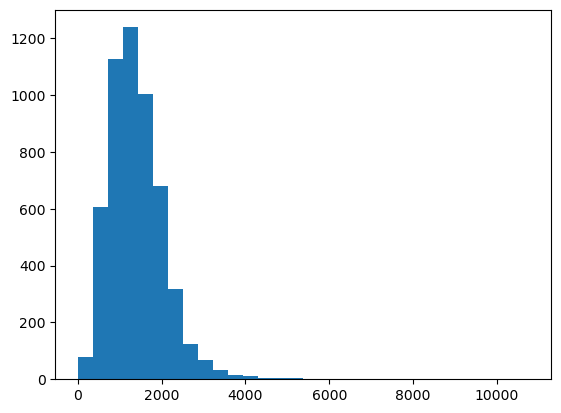

In [75]:
plt.hist(day24["nucleus_area"],bins=30)

In [73]:
day24[(day24["nucleus_area"]<7000) & (day24["nucleus_area"]>500)]["nucleus_area"].describe()
# day24.sort_values(by="nucleus_area", ascending=True).head(n=20)

count    5121.000000
mean     1444.087678
std       645.177728
min       501.000000
25%       985.000000
50%      1352.000000
75%      1790.000000
max      6945.000000
Name: nucleus_area, dtype: float64

In [ ]:
day24_filtered = day24.sort_values(by="nucleus_area", ascending=True).head(n=20)

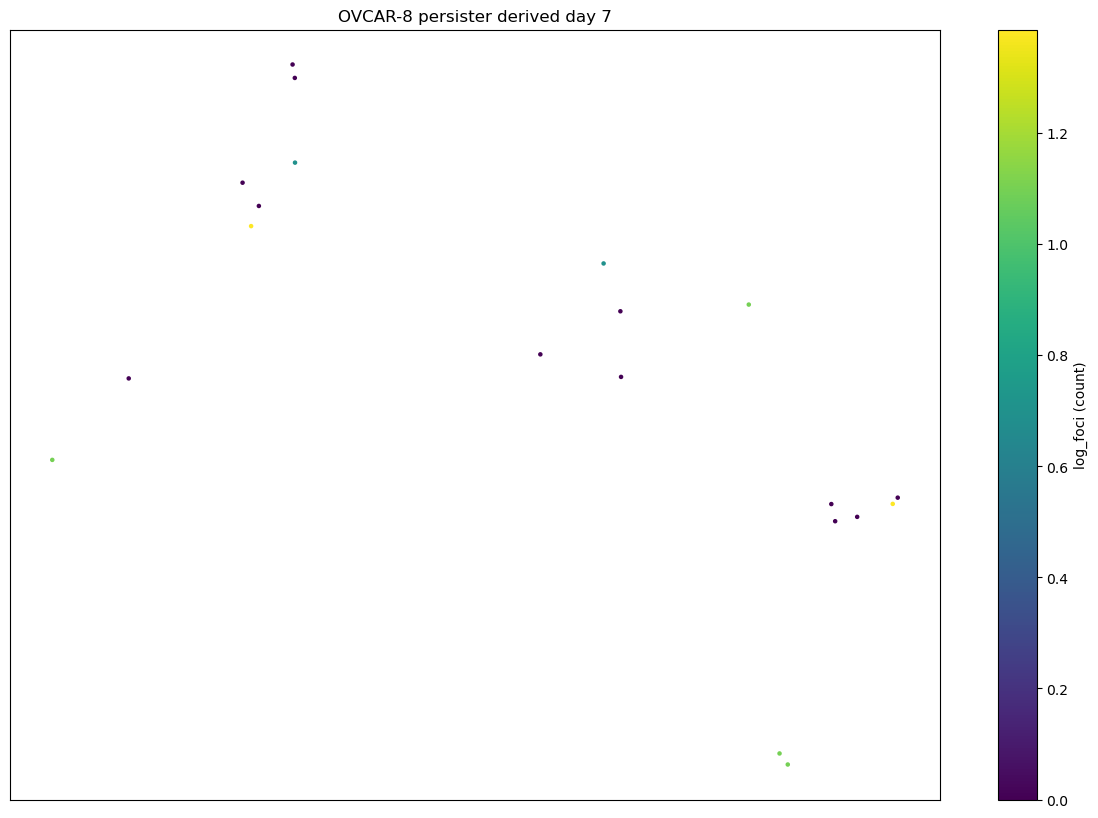

In [43]:
plt.figure(figsize=(15,10))

plt.scatter(
    day24_filtered["nucleus_i"],
    day24_filtered["nucleus_j"],
    c=day24_filtered["log_foci"],
    s=5,
    cmap="viridis"
)

plt.xticks(ticks=[])
plt.yticks(ticks=[])
plt.colorbar(label="log_foci (count)")
#plt.gca().invert_yaxis()
plt.title("OVCAR-8 persister derived day 7")
plt.show()

In [ ]:

# Plotting correlation heatmap
dataplot = sns.heatmap(df.corr(numeric_only=True))

# Displaying heatmap
plt.show()

In [ ]:
scaled_statistics = StandardScaler().fit_transform(df)

type(scaled_statistics), scaled_statistics.shape

In [ ]:
fix = np.where(np.isnan(scaled_statistics), 0, scaled_statistics)

In [ ]:
reducer = umap.UMAP()
embedding = reducer.fit_transform(fix)
type(embedding), embedding.shape

In [ ]:
sns.scatterplot(x=embedding[:, 0], 
                    y=embedding[:, 1],
                    data = df,
                    hue='foci_area')

plt.xlabel('UMAP1')
plt.ylabel('UMAP2')

In [ ]:
num_classes = 2

kmeans = KMeans(n_clusters=num_classes, random_state=42).fit(embedding)

kmeans_prediction = kmeans.predict(embedding)

sns.scatterplot(x=embedding[:, 0], 
                    y=embedding[:, 1],
                    hue=kmeans_prediction)

In [ ]:
sns.scatterplot(x=embedding[:, 0], 
                    y=embedding[:, 1],
                    hue=kmeans_prediction)

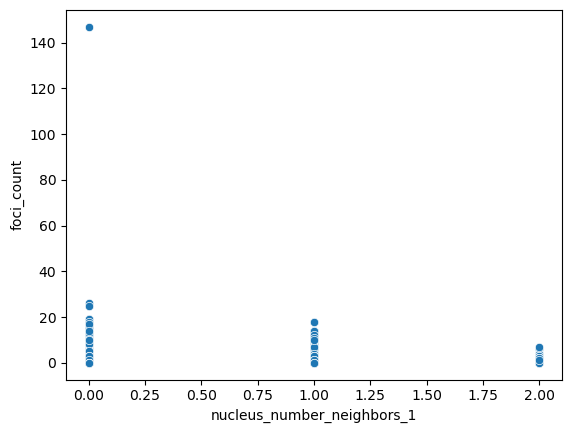

In [49]:
sns.scatterplot(data=df_clean, x="nucleus_number_neighbors_1", y="foci_count")
plt.show()

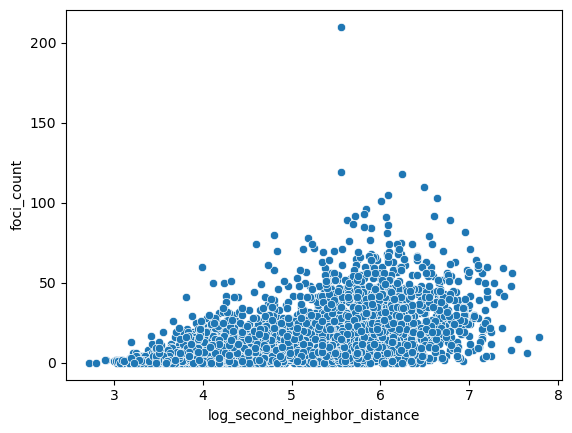

In [70]:
sns.scatterplot(data=df_clean, x="log_second_neighbor_distance", y="foci_count")
plt.show()

In [ ]:
df["density_bin"] = pd.qcut(df["density_2"], 10)

sns.boxplot(
    data=df,
    x="density_bin",
    y="foci_count"
)

In [18]:
df["crowding"] = 1 / (
    df["nucleus_first_neighbor_distance"] +
    df["nucleus_second_neighbor_distance"]
)

/var/folders/0z/cjqt0cf96g16c0wxg68l427w0000gn/T/ipykernel_11552/1430088498.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["crowding"] = 1 / (


In [ ]:
data["nuclei_i"]

In [ ]:
df3 = pd.concat([df, data[["nuclei_i"] + ["nuclei_j"]]], axis=1, join="outer", sort=False).reset_index()

In [ ]:
df3

In [ ]:
df = df3

In [ ]:
coords = day24.drop_co

,foci_count,label.1,nuclei_area,nuclei_i,nuclei_j,foci_area,nucleus_number_neighbors_1,nucleus_percent_touching_1,nucleus_first_neighbor_distance,nucleus_second_neighbor_distance,nucleus_angle_between_neighbors
0,4,1,2717.0,702.826279,23104.128082,84,1,0.269625,45.028147,356.689278,63.122746
1,0,2,1672.0,725.440191,23143.065789,0,1,0.373206,45.028147,338.722585,110.067377
2,115,3,47858.0,827.004931,19604.518137,2292,0,0.000000,2285.094352,2508.669848,75.143949
3,209,4,69456.0,846.331606,24623.286484,2352,0,0.000000,1485.149163,1525.921370,0.727305
4,4,5,1799.0,1058.934964,23083.784880,39,0,0.000000,338.722585,356.689278,6.809877
...,...,...,...,...,...,...,...,...,...,...,...
5579,0,5580,313.0,41141.648562,21164.952077,0,0,0.000000,198.964734,650.819766,29.652683
5580,0,5581,344.0,41229.020349,20986.197674,0,0,0.000000,198.964734,487.943582,138.708792
5581,0,5582,622.0,41330.006431,23561.048232,0,1,0.157025,24.680533,53.098282,28.441146
5582,0,5583,586.0,41327.680887,23614.095563,0,0,0.000000,33.524676,53.098282,20.524922


In [12]:
from sklearn.neighbors import NearestNeighbors

#coords = day24[["nucleus_i","nucleus_j"]].values
coords = day24[["nuclei_i","nuclei_j"]]

nbrs = NearestNeighbors(n_neighbors=6).fit(coords)
distances, _ = nbrs.kneighbors(coords)

# rk = distances[:,5]

# df["density_k5"] = 5 / (np.pi * rk**2)

In [13]:
distances

array([[   0.        ,   45.02814745,  356.68927839,  591.03823305,
        1525.92136965, 2138.65766022],
       [   0.        ,   45.02814745,  338.72258478,  600.07199735,
        1485.14916326, 2108.24673341],
       [   0.        , 2285.09435174, 2508.6698476 , 2550.36283835,
        2743.98736125, 2841.22850194],
       ...,
       [   0.        ,   24.68053275,   53.09828194,  898.65813419,
        1301.85109568, 1666.19035971],
       [   0.        ,   33.52467618,   53.09828194,  880.40608079,
        1261.56703522, 1666.81054155],
       [   0.        ,   24.68053275,   33.52467618,  901.88711396,
        1292.93974561, 1677.99321141]], shape=(5584, 6))

In [22]:
df["density_k5"].describe()

count    7.124000e+03
mean     3.134689e-04
std      3.955240e-03
min      1.416963e-07
25%      6.549622e-06
50%      1.466115e-05
75%      3.067678e-05
max      7.957747e-02
Name: density_k5, dtype: float64

In [ ]:
sns.histplot(df["density_k5"], bins=50)
plt.show()

In [24]:
df["log_density_k5"] = np.log10(df["density_k5"])
df["log_foci"] = np.log1p(df["foci_count"])

/var/folders/0z/cjqt0cf96g16c0wxg68l427w0000gn/T/ipykernel_11552/1846715062.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["log_density_k5"] = np.log10(df["density_k5"])
/var/folders/0z/cjqt0cf96g16c0wxg68l427w0000gn/T/ipykernel_11552/1846715062.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["log_foci"] = np.log1p(df["foci_count"])


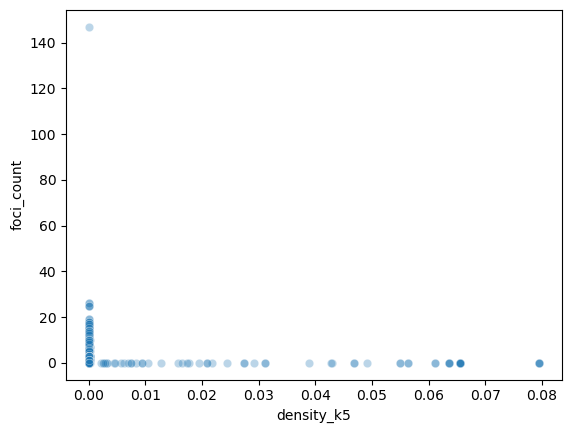

In [25]:
sns.scatterplot(
    data=df,
    x="density_k5",
    y="foci_count",
    alpha=0.3
)
plt.show()

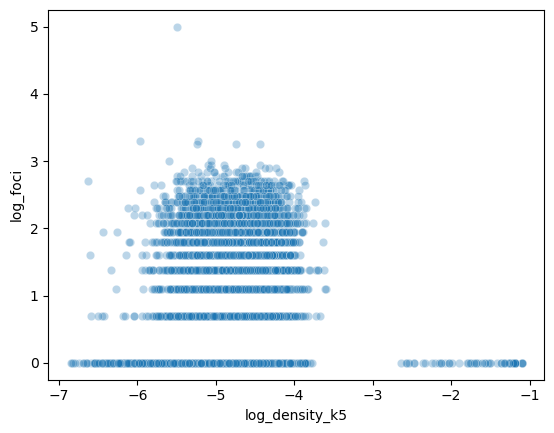

In [26]:
sns.scatterplot(
    data=df,
    x="log_density_k5",
    y="log_foci",
    alpha=0.3
)
plt.show()

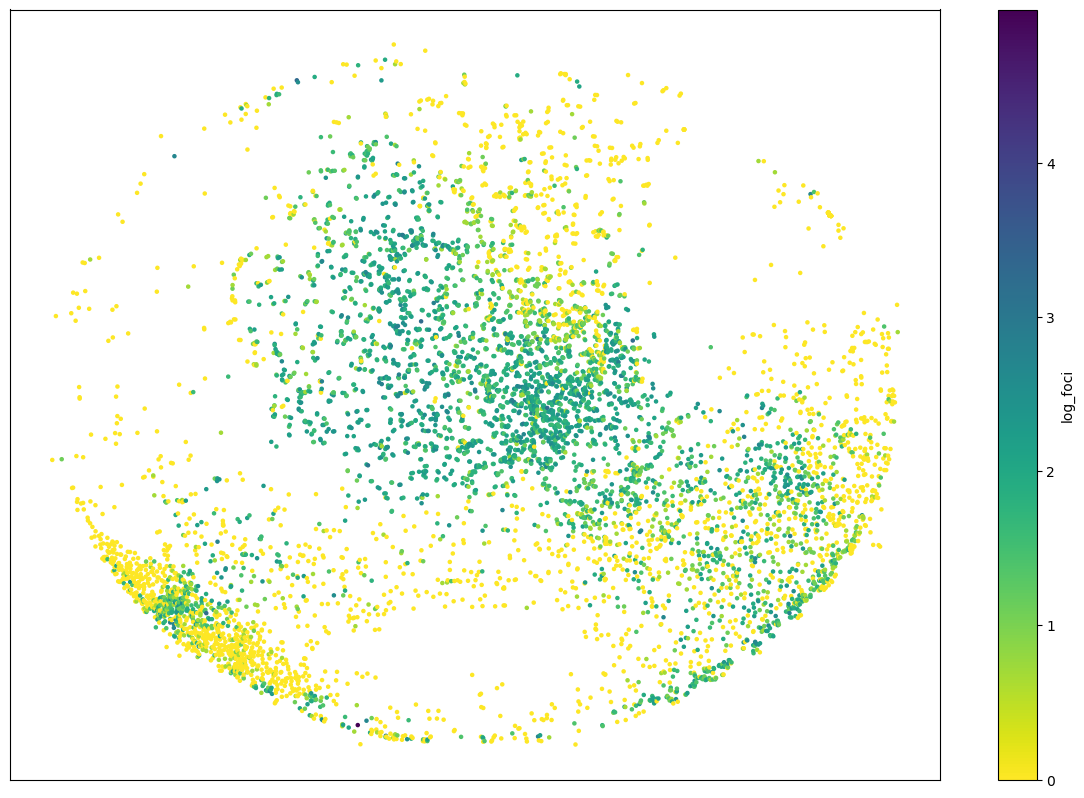

In [28]:
plt.figure(figsize=(15,10))

plt.scatter(
    df["nucleus_i"],
    df["nucleus_j"],
    c=df["log_foci"],
    s=5,
    cmap="viridis_r"
)
plt.xticks(ticks=[])
plt.yticks(ticks=[])
plt.colorbar(label="log_foci")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
plt.figure(figsize=(20,18))

plt.scatter(
    df["nuclei_i"],
    df["nuclei_j"],
    c=df["log_density_k5"],
    s=5,
    cmap="viridis"
)

plt.colorbar(label="log_density_k5")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
plt.scatter(
    df["nuclei_i"],
    df["nuclei_j"],
    c=df["log_density_k5"],
    s=np.sqrt(df["foci_count"]+1)*3,
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(label="density")
plt.gca().invert_yaxis()

In [30]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

df = df.copy()

df["log_density_k5"] = np.log(df["density_k5"])
# safer if any zeros might exist:
# df["log_density_k5"] = np.log1p(df["density_k5"])

model = smf.glm(
    formula="foci_count ~ log_density_k5 + nucleus_area",
    data=df,
    family=sm.families.NegativeBinomial()
).fit()

print(model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:             foci_count   No. Observations:                 7124
Model:                            GLM   Df Residuals:                     7121
Model Family:        NegativeBinomial   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -16407.
Date:                Wed, 18 Mar 2026   Deviance:                       10078.
Time:                        19:15:05   Pearson chi2:                 2.02e+04
No. Iterations:                    16   Pseudo R-squ. (CS):            0.02575
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          2.2781      0.120     19.

/Users/hannahbolen/miniforge3/envs/slide_env/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


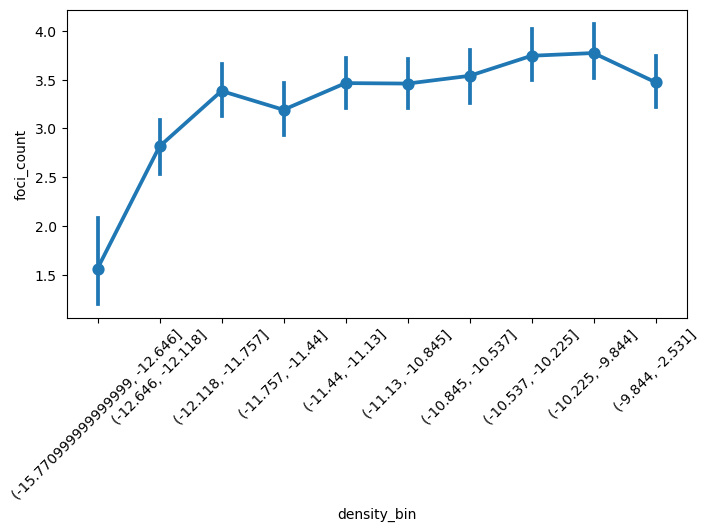

In [31]:
df["density_bin"] = pd.qcut(df["log_density_k5"], 10)

plt.figure(figsize=(8,4))

sns.pointplot(
    data=df,
    x="density_bin",
    y="foci_count",
    errorbar=("ci",95)
)

plt.xticks(rotation=45)
plt.show()